In [ ]:
#pip install pyod
!git clone https://github.com/Ignas12345/Magistras_pagalbines_funkcijos.git
import numpy as np
import pandas as pd
from Magistras_pagalbines_funkcijos.pagalbines_funkcijos import *


fatal: destination path 'Magistras_pagalbines_funkcijos' already exists and is not an empty directory.


Pirma apžiūrim mėginius - atsifiltruojam "nereikalingus", atsidedam duomenų testavimui

In [ ]:
url_gtex_patient_data = 'https://raw.githubusercontent.com/Ignas12345/Magistras_knygutes_ir_duomenys/refs/heads/main/duomenys/TCGA_TGCT_ir_GTEx/GTEx_Analysis_v10_Annotations_SubjectPhenotypesDS.txt'
url_gtex_sample_data = 'https://raw.githubusercontent.com/Ignas12345/Magistras_knygutes_ir_duomenys/refs/heads/main/duomenys/TCGA_TGCT_ir_GTEx/GTEx_Analysis_v10_Annotations_SampleAttributesDS.txt'
url_TCGA_mdata = 'https://raw.githubusercontent.com/Ignas12345/Magistras_knygutes_ir_duomenys/refs/heads/main/duomenys/TCGA_TGCT_ir_GTEx/TCGA-TGCT_mdata.csv'
data_subfolder = 'duomenys/TCGA_TGCT'
url_labels = 'https://raw.githubusercontent.com/Ignas12345/Magistras_antras_dublis/refs/heads/main/' + data_subfolder + '/primary_diagnoses.csv'

gtex_patient_data = pd.read_csv(url_gtex_patient_data, sep='\t')
gtex_patient_data.set_index('SUBJID', inplace=True)

gtex_sample_data = pd.read_csv(url_gtex_sample_data, sep='\t')
gtex_sample_data.set_index('SAMPID', inplace=True)
gtex_sample_data_area = gtex_sample_data[['SMTS', 'SMTSD']].copy()

TCGA_mdata = pd.read_csv(url_TCGA_mdata, index_col=0, sep = ';')
TCGA_mdata.set_index('sample_ids', inplace=True)

<ipython-input-3-eb5a765020a0>:10: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  gtex_sample_data = pd.read_csv(url_gtex_sample_data, sep='\t')


In [ ]:
gene_df = pd.read_csv('/content/gene_raw_counts.csv', index_col=0)

In [ ]:
gtex_samples = gtex_sample_data.index.intersection(gene_df.columns)

Inspect if gtex samples need filtering

In [ ]:
len(gtex_samples)

414

In [ ]:
sum(gtex_sample_data_area.loc[gtex_samples]['SMTSD'] == 'Testis')

414

Find groups to filter in TCGA_TGCT samples

In [ ]:
tcga_samples_with_prior_treatment = TCGA_mdata.index[TCGA_mdata['prior_treatments'] == 'Yes'].tolist()
print('tcga_samples_with_prior_treatment = ' + str(tcga_samples_with_prior_treatment))

tcga_samples_with_prior_treatment = ['TCGA-2G-AAGY-01A', 'TCGA-2G-AAGY-05A', 'TCGA-2G-AAGT-01A', 'TCGA-2G-AAKG-01A', 'TCGA-2G-AAKG-05A', 'TCGA-2G-AAGJ-01A', 'TCGA-4K-AAAL-01A', 'TCGA-2G-AAFG-01A', 'TCGA-2G-AAFG-05A', 'TCGA-XE-AAOB-01A', 'TCGA-2G-AAGX-01A', 'TCGA-2G-AAGK-01A', 'TCGA-2G-AAG3-01A', 'TCGA-2G-AAF8-01A', 'TCGA-VF-A8AD-01A', 'TCGA-2G-AAH0-01A', 'TCGA-ZM-AA0N-01A', 'TCGA-2G-AAFL-01A', 'TCGA-2G-AAL7-01A', 'TCGA-SN-A84Y-01A', 'TCGA-XE-AANJ-01A']


In [ ]:
mixed_germ_cell_tumor_outlieris = ['TCGA-SN-A84W-01A']
tcga_samples_with_prior_malignancy = ['TCGA-2G-AAFE-01A']

tcga_samples_with_prior_treatment = ['TCGA-2G-AAGY-01A', 'TCGA-2G-AAGY-05A', 'TCGA-2G-AAGT-01A', 'TCGA-2G-AAKG-01A', 'TCGA-2G-AAKG-05A', 'TCGA-2G-AAGJ-01A', 'TCGA-4K-AAAL-01A', 'TCGA-2G-AAFG-01A', 'TCGA-2G-AAFG-05A', 'TCGA-XE-AAOB-01A', 'TCGA-2G-AAGX-01A', 'TCGA-2G-AAGK-01A', 'TCGA-2G-AAG3-01A', 'TCGA-2G-AAF8-01A', 'TCGA-VF-A8AD-01A', 'TCGA-2G-AAH0-01A', 'TCGA-ZM-AA0N-01A', 'TCGA-2G-AAFL-01A', 'TCGA-2G-AAL7-01A', 'TCGA-SN-A84Y-01A', 'TCGA-XE-AANJ-01A']

tcga_samples_with_different_resection_sites = ['TCGA-2G-AAGY-01A', 'TCGA-2G-AAGY-05A', 'TCGA-2G-AAG0-01A', 'TCGA-2G-AAGT-01A', 'TCGA-2G-AAKG-01A', 'TCGA-2G-AAKG-05A', 'TCGA-2G-AAGJ-01A', 'TCGA-4K-AAAL-01A', 'TCGA-2G-AAFG-01A', 'TCGA-2G-AAFG-05A', 'TCGA-XE-AAOB-01A', 'TCGA-2G-AAGX-01A', 'TCGA-2G-AAGK-01A', 'TCGA-2G-AAG3-01A', 'TCGA-2G-AAF8-01A', 'TCGA-VF-A8AD-01A', 'TCGA-2G-AAH0-01A', 'TCGA-ZM-AA0N-01A', 'TCGA-2G-AAFL-01A', 'TCGA-2G-AAL7-01A', 'TCGA-SN-A84Y-01A', 'TCGA-XE-AANJ-01A']

#sitas sutampa su virsutiniu sarasu
tcga_samples_with_diagnosis_not_primary_disease = ['TCGA-2G-AAGY-01A', 'TCGA-2G-AAGY-05A', 'TCGA-2G-AAG0-01A', 'TCGA-2G-AAGT-01A', 'TCGA-2G-AAKG-01A', 'TCGA-2G-AAKG-05A', 'TCGA-2G-AAGJ-01A', 'TCGA-4K-AAAL-01A', 'TCGA-2G-AAFG-01A', 'TCGA-2G-AAFG-05A', 'TCGA-XE-AAOB-01A', 'TCGA-2G-AAGX-01A', 'TCGA-2G-AAGK-01A', 'TCGA-2G-AAG3-01A', 'TCGA-2G-AAF8-01A', 'TCGA-VF-A8AD-01A', 'TCGA-2G-AAH0-01A', 'TCGA-ZM-AA0N-01A', 'TCGA-2G-AAFL-01A', 'TCGA-2G-AAL7-01A', 'TCGA-SN-A84Y-01A', 'TCGA-XE-AANJ-01A']

#cia gali buti klaida - kad kai zmogus turejo daugiau negu viena diagnoze (pvz. tyrimas buvo kartotas kelis kart, tai tiesiog parašė "Not Reported". Nes šiaip nuėjus į TCGA puslapį, tai kai kurie iš šių mėginių tikrai turi priskirtą diagnozę)
tcga_samples_with_not_rep_primary_diag = ['TCGA-2G-AAKO-01A', 'TCGA-2G-AAKO-05A', 'TCGA-2G-AALY-01A', 'TCGA-2G-AAGY-01A', 'TCGA-2G-AAGY-05A', 'TCGA-2G-AALO-01A', 'TCGA-2G-AAKG-01A', 'TCGA-2G-AAKG-05A', 'TCGA-2G-AAFG-01A', 'TCGA-2G-AAFG-05A', 'TCGA-2G-AALG-01A', 'TCGA-2G-AAM3-01A', 'TCGA-2G-AALX-01A', 'TCGA-2G-AAGX-01A', 'TCGA-2G-AAG3-01A', 'TCGA-2G-AAF8-01A', 'TCGA-2G-AALZ-01A', 'TCGA-2G-AALF-01A', 'TCGA-2G-AALN-01A', 'TCGA-2G-AALW-01A', 'TCGA-2G-AAFL-01A', 'TCGA-2G-AAM4-01A', 'TCGA-2G-AALS-01A', 'TCGA-2G-AALR-01A', 'TCGA-2G-AAM2-01A', 'TCGA-2G-AALT-01A', 'TCGA-2G-AALQ-01A']

list_names = [tcga_samples_with_prior_treatment, tcga_samples_with_prior_malignancy, tcga_samples_with_different_resection_sites, tcga_samples_with_diagnosis_not_primary_disease, tcga_samples_with_not_rep_primary_diag, mixed_germ_cell_tumor_outlieris]

In [ ]:
list_of_samples_to_filter = []
for ls in list_names:
  for sample in ls:
    if sample not in list_of_samples_to_filter:
      list_of_samples_to_filter.append(sample)

In [ ]:
# print list_of_samples_to_filter all on one line
print(*list_of_samples_to_filter, sep=', ')

TCGA-2G-AAGY-01A, TCGA-2G-AAGY-05A, TCGA-2G-AAGT-01A, TCGA-2G-AAKG-01A, TCGA-2G-AAKG-05A, TCGA-2G-AAGJ-01A, TCGA-4K-AAAL-01A, TCGA-2G-AAFG-01A, TCGA-2G-AAFG-05A, TCGA-XE-AAOB-01A, TCGA-2G-AAGX-01A, TCGA-2G-AAGK-01A, TCGA-2G-AAG3-01A, TCGA-2G-AAF8-01A, TCGA-VF-A8AD-01A, TCGA-2G-AAH0-01A, TCGA-ZM-AA0N-01A, TCGA-2G-AAFL-01A, TCGA-2G-AAL7-01A, TCGA-SN-A84Y-01A, TCGA-XE-AANJ-01A, TCGA-2G-AAFE-01A, TCGA-2G-AAG0-01A, TCGA-2G-AAKO-01A, TCGA-2G-AAKO-05A, TCGA-2G-AALY-01A, TCGA-2G-AALO-01A, TCGA-2G-AALG-01A, TCGA-2G-AAM3-01A, TCGA-2G-AALX-01A, TCGA-2G-AALZ-01A, TCGA-2G-AALF-01A, TCGA-2G-AALN-01A, TCGA-2G-AALW-01A, TCGA-2G-AAM4-01A, TCGA-2G-AALS-01A, TCGA-2G-AALR-01A, TCGA-2G-AAM2-01A, TCGA-2G-AALT-01A, TCGA-2G-AALQ-01A


In [ ]:
tcga_samples_to_keep = TCGA_mdata.index[~TCGA_mdata.index.isin(list_of_samples_to_filter)].tolist()

In [ ]:
len(tcga_samples_to_keep)


115

Čia atfiltruojam GTEx mėginius, kad jų amžiaus grupė maždaug sutaptų su TCGA likusiais mėginiais

In [ ]:
TCGA_ages = pd.DataFrame(TCGA_mdata['age_at_index'][tcga_samples_to_keep].copy())
TCGA_ages.rename(columns={'age_at_index': 'Age'}, inplace=True)
TCGA_diagnoses = TCGA_mdata['primary_diagnosis'][tcga_samples_to_keep].copy()

In [ ]:
#for each GTEX sample get SUBJID
sample_subj_id_dict = {}
for subjid in gtex_patient_data.index:
  for sample_id in gtex_samples:
    if subjid in sample_id:
      sample_subj_id_dict[sample_id] = subjid
ages = []
for sample in gtex_samples:
  age = gtex_patient_data.loc[sample_subj_id_dict[sample]]['AGE']
  ages.append(age)
gtex_ages = pd.DataFrame(index=gtex_samples)
gtex_ages['Age_Bin'] = ages

In [ ]:
TCGA_ages

,Age,Age_Bin
sample_ids,,
TCGA-XE-AAOD-01A,39.0,30-39
TCGA-2G-AAEW-01A,31.0,30-39
TCGA-2G-AAF6-01A,28.0,20-29
TCGA-XY-A8S3-01B,24.0,20-29
TCGA-2X-A9D5-01A,49.0,40-49
...,...,...
TCGA-XE-AANV-01A,52.0,50-59
TCGA-2G-AAFH-01A,38.0,30-39
TCGA-SB-A6J6-01A,22.0,20-29


In [ ]:
gtex_ages

,Age_Bin
GTEX-111CU-1726-SM-5EGHM,50-59
GTEX-111FC-1926-SM-5GZYC,60-69
GTEX-111VG-1926-SM-5GIDO,60-69
GTEX-111YS-2026-SM-5EGGL,60-69
GTEX-117XS-2026-SM-5GID1,60-69
...,...
GTEX-ZVZP-2226-SM-57WBF,50-59
GTEX-ZY6K-1726-SM-5GZX8,50-59
GTEX-ZYFC-0126-SM-5GIEH,50-59
GTEX-ZYT6-2726-SM-5GICP,30-39


from matplotlib import pyplot as plt
import seaborn as sns
gtex_ages.groupby('Age_Bin').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
#ChatGPT funkcija kad atrinkti meginius pagal amziu
def stratified_sampling(tcga_df, gtex_df, target_gtex_size=250):
    """
    Performs stratified sampling of GTEx samples to match TCGA's age distribution.

    Parameters:
    - tcga_df: DataFrame containing TCGA samples with an 'Age' column.
    - gtex_df: DataFrame containing GTEx samples with an 'Age' column.
    - target_gtex_size: Number of GTEx samples to retain.

    Returns:
    - Sampled GTEx DataFrame with approximately target_gtex_size rows.
    """
    # Define age bins based on histogram intervals
    age_bins = [14, 20, 30, 40, 50, 60, 70, 80]  # Adjust as needed
    age_labels = ["<20","20-29", "30-39", "40-49", "50-59", "60-69", "70-79"]

    # Assign age bins to TCGA and GTEx
    tcga_df["Age_Bin"] = pd.cut(tcga_df["Age"], bins=age_bins, labels=age_labels, right=False)
    #gtex_df["Age_Bin"] = pd.cut(gtex_df["Age"], bins=age_bins, labels=age_labels, right=False)

    # Get TCGA age distribution
    tcga_counts = tcga_df["Age_Bin"].value_counts(normalize=True)  # Proportions

    # Determine GTEx sample size per bin
    target_bin_counts = (tcga_counts * target_gtex_size).astype(int)

    # Sample from GTEx according to target distribution
    sampled_gtex = []
    for bin_range, target_count in target_bin_counts.items():
        bin_samples = gtex_df[gtex_df["Age_Bin"] == bin_range]
        if len(bin_samples) >= target_count:
            sampled_gtex.append(bin_samples.sample(target_count, random_state=42))
        else:
            sampled_gtex.append(bin_samples)  # Take all available if not enough

    # Concatenate sampled data
    sampled_gtex_df = pd.concat(sampled_gtex).drop(columns=["Age_Bin"])

    return sampled_gtex_df

In [ ]:
resampled_gtex_samples = stratified_sampling(TCGA_ages, gtex_ages, target_gtex_size=250)

In [ ]:
TCGA_ages['Age'].loc[:]

,Age
sample_ids,
TCGA-XE-AAOD-01A,39.0
TCGA-2G-AAEW-01A,31.0
TCGA-2G-AAF6-01A,28.0
TCGA-XY-A8S3-01B,24.0
TCGA-2X-A9D5-01A,49.0
...,...
TCGA-XE-AANV-01A,52.0
TCGA-2G-AAFH-01A,38.0
TCGA-SB-A6J6-01A,22.0


<ipython-input-194-7b678a95fbcf>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  TCGA_ages.groupby('Age_Bin').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))


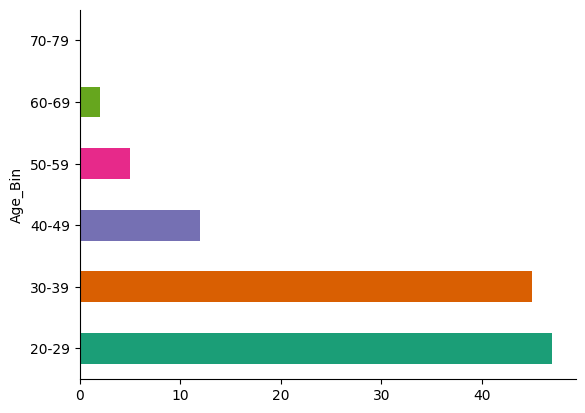

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
TCGA_ages.groupby('Age_Bin').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
resampled_gtex_samples = resampled_gtex_samples.index.to_list()
gtex_ages.loc[resampled_gtex_samples]

,Age_Bin
GTEX-11NSD-1026-SM-5N9BE,20-29
GTEX-11P82-1526-SM-5BC5M,20-29
GTEX-11TT1-2226-SM-5GU6B,20-29
GTEX-12C56-1426-SM-5FQSW,20-29
GTEX-12WSE-0126-SM-HLJQY,20-29
...,...
GTEX-UPJH-0126-SM-4IHLL,50-59
GTEX-1B8SF-2926-SM-731DL,60-69
GTEX-15RIE-0626-SM-6M47G,60-69
GTEX-132QS-1226-SM-5P9GD,60-69


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('Age_Bin').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
len(set(resampled_gtex_samples))

118

In [ ]:
final_list_of_samples = tcga_samples_to_keep + resampled_gtex_samples

In [ ]:
tcga_labels = create_labels_from_df(url_labels, tcga_samples_to_keep)

In [ ]:
#create a dataframe from tcga labels using keys as index
tcga_labels_df = pd.DataFrame.from_dict(tcga_labels, orient='index', columns=['label'])
tcga_labels_df.index.name = 'sample_id'

In [ ]:
tcga_labels_df

,label
sample_id,
TCGA-XE-AAOD-01A,Mixed germ cell tumor
TCGA-2G-AAEW-01A,"Seminoma, NOS"
TCGA-2G-AAF6-01A,"Seminoma, NOS"
TCGA-XY-A8S3-01B,"Embryonal carcinoma, NOS"
TCGA-2X-A9D5-01A,"Seminoma, NOS"
...,...
TCGA-XE-AANV-01A,"Seminoma, NOS"
TCGA-2G-AAFH-01A,"Seminoma, NOS"
TCGA-SB-A6J6-01A,"Seminoma, NOS"


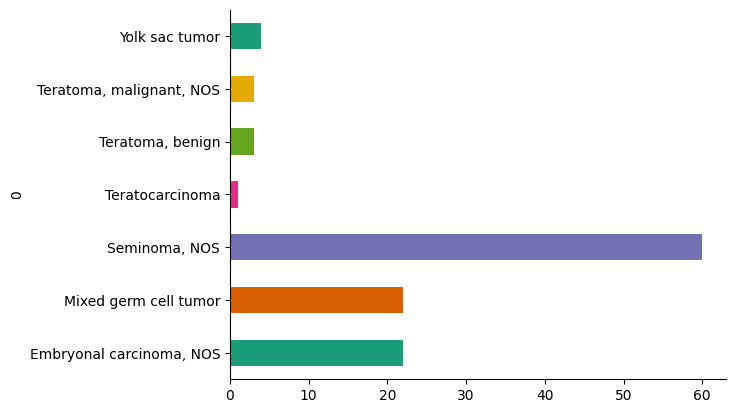

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
tcga_labels_df.groupby(0).size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
#set aside 10% of the data for testing from the classes "Mixed germ cell tumor" and "Embryonal carcinoma" and 15% from "Seminoma, NOS":
def split_test_set(tcga_df, test_sizes={"Mixed germ cell tumor": 0.1, "Embryonal carcinoma, NOS": 0.1, "Seminoma, NOS": 0.10}):
    """
    Splits a portion of the TCGA dataset into a test set based on the given class proportions.

    Parameters:
    - tcga_df: DataFrame containing TCGA samples with a 'Diagnosis' column.
    - test_sizes: Dictionary specifying the proportion of each class to set aside for testing.

    Returns:
    - train_df: DataFrame with training data.
    - test_df: DataFrame with test data.
    """
    test_samples = []
    train_samples = []

    for diagnosis, test_ratio in test_sizes.items():
        class_samples = tcga_df[tcga_df["label"] == diagnosis]
        test_size = int(len(class_samples) * test_ratio)

        test_samples.append(class_samples.sample(test_size, random_state=42))
        train_samples.append(class_samples.drop(test_samples[-1].index))

    # Collect remaining samples not in the specified classes
    remaining_samples = tcga_df[~tcga_df["label"].isin(test_sizes.keys())]
    train_samples.append(remaining_samples)

    # Concatenate test and train sets
    test_df = pd.concat(test_samples)
    train_df = pd.concat(train_samples)

    return train_df, test_df

train_samples, test_samples = split_test_set(tcga_labels_df)

In [ ]:
tcga_train_samples = train_samples.index.to_list()
tcga_test_samples = test_samples.index.to_list()
print('tcga_train_samples = ' + str(tcga_train_samples))
print('tcga_test_samples = ' + str(tcga_test_samples))

tcga_train_samples = ['TCGA-YU-AA61-01A', 'TCGA-2G-AAGC-01A', 'TCGA-W4-A7U2-01A', 'TCGA-2G-AAH2-01A', 'TCGA-2G-AAL5-01A', 'TCGA-W4-A7U3-01A', 'TCGA-SN-A84X-01A', 'TCGA-SN-A6IS-01A', 'TCGA-2G-AAGF-01A', 'TCGA-2G-AAGS-01A', 'TCGA-2G-AAKM-01A', 'TCGA-2G-AAGG-01A', 'TCGA-2G-AAH4-01A', 'TCGA-2G-AAFZ-01A', 'TCGA-XE-AAOJ-01A', 'TCGA-2G-AAGP-01A', 'TCGA-X3-A8G4-01A', 'TCGA-2G-AAG7-01A', 'TCGA-2G-AAGI-01A', 'TCGA-2G-AAGI-05A', 'TCGA-VF-A8A8-01A', 'TCGA-2G-AAFY-01A', 'TCGA-YU-AA4L-01A', 'TCGA-XY-A8S2-01A', 'TCGA-2G-AAGE-01A', 'TCGA-2G-AAGO-01A', 'TCGA-2G-AAFO-01A', 'TCGA-2G-AAFI-01A', 'TCGA-YU-A90Y-01A', 'TCGA-YU-A90P-01A', 'TCGA-2G-AAFM-01A', 'TCGA-2G-AAGN-01A', 'TCGA-2G-AAKH-01A', 'TCGA-2G-AAG8-01A', 'TCGA-2G-AAGA-01A', 'TCGA-2G-AAKD-01A', 'TCGA-XE-A8H1-01A', 'TCGA-2G-AAFN-01A', 'TCGA-2G-AAGZ-01A', 'TCGA-2G-AAKL-01A', 'TCGA-2G-AAF6-01A', 'TCGA-2X-A9D5-01A', 'TCGA-2X-A9D6-01A', 'TCGA-S6-A8JY-01A', 'TCGA-2G-AAEX-01A', 'TCGA-4K-AA1H-01A', 'TCGA-YU-A90S-01A', 'TCGA-2G-AAG9-01A', 'TCGA-ZM-AA0D-01A'

In [ ]:
resampled_gtex_samples_df = pd.DataFrame(resampled_gtex_samples, columns=['sample_id'])
resampled_gtex_samples_df.set_index('sample_id', inplace=True)

In [ ]:
def split_test_set_gtex(all_samples):
    """
    Splits a portion of the TCGA dataset into a test set based on the given class proportions.

    Parameters:
    - tcga_df: DataFrame containing TCGA samples with a 'Diagnosis' column.
    - test_sizes: Dictionary specifying the proportion of each class to set aside for testing.

    Returns:
    - train_df: DataFrame with training data.
    - test_df: DataFrame with test data.
    """
    test_samples = []
    train_samples = []

    test_size = 17

    test_samples.append(all_samples.sample(test_size, random_state=42))
    train_samples.append(all_samples.drop(test_samples[-1].index))

    # Concatenate test and train sets
    test_df = pd.concat(test_samples)
    train_df = pd.concat(train_samples)

    return train_df, test_df

train_samples_gtex, test_samples_gtex = split_test_set_gtex(resampled_gtex_samples_df)

In [ ]:
gtex_train_samples = train_samples_gtex.index.to_list()
gtex_test_samples = test_samples_gtex.index.to_list()
print('gtex_train_samples = ' + str(gtex_train_samples))
print('gtex_test_samples = ' + str(gtex_test_samples))

gtex_train_samples = ['GTEX-11NSD-1026-SM-5N9BE', 'GTEX-11P82-1526-SM-5BC5M', 'GTEX-11TT1-2226-SM-5GU6B', 'GTEX-12C56-1426-SM-5FQSW', 'GTEX-144GM-0426-SM-5Q5C8', 'GTEX-15RIF-1826-SM-6M469', 'GTEX-17EUY-0926-SM-H7OFW', 'GTEX-17MFQ-0826-SM-793C8', 'GTEX-183FY-1926-SM-7KFRI', 'GTEX-1IDJF-2226-SM-AHZ2T', 'GTEX-1JKYR-1626-SM-AHZ3L', 'GTEX-1K2DU-2226-SM-CXZJY', 'GTEX-1KANA-1626-SM-CXZL2', 'GTEX-1LBAC-1826-SM-D3L9X', 'GTEX-1OJC3-2026-SM-F2I25', 'GTEX-1PIGE-1626-SM-DPRZE', 'GTEX-1PPH8-1226-SM-DPRXO', 'GTEX-1RAZA-2126-SM-EVR4A', 'GTEX-1S5ZA-1726-SM-HLJR2', 'GTEX-1S831-2026-SM-EXOJP', 'GTEX-O5YT-2126-SM-G8W7R', 'GTEX-PW2O-1426-SM-48TCD', 'GTEX-R55E-0726-SM-48FCZ', 'GTEX-S4Q7-1226-SM-4AD5I', 'GTEX-SNMC-1026-SM-4DM7K', 'GTEX-T5JC-0726-SM-4DM55', 'GTEX-WHSE-0426-SM-4M1XO', 'GTEX-WOFM-1126-SM-4M9QN', 'GTEX-XPT6-1626-SM-4B655', 'GTEX-XQ3S-2726-SM-4BOP2', 'GTEX-YJ8A-2226-SM-H7OFM', 'GTEX-ZA64-1626-SM-5CVME', 'GTEX-ZTX8-1126-SM-51MRM', 'GTEX-ZVTK-0126-SM-57WDG', 'GTEX-ZZ64-1126-SM-5GZXY', 'GTEX-11EQ9-1

put test and training data into dataframes with patient ages and diagnoses if applicable

In [ ]:
gtex_train_samples = ['GTEX-11NSD-1026-SM-5N9BE', 'GTEX-11P82-1526-SM-5BC5M', 'GTEX-11TT1-2226-SM-5GU6B', 'GTEX-12C56-1426-SM-5FQSW', 'GTEX-144GM-0426-SM-5Q5C8', 'GTEX-15RIF-1826-SM-6M469', 'GTEX-17EUY-0926-SM-H7OFW', 'GTEX-17MFQ-0826-SM-793C8', 'GTEX-183FY-1926-SM-7KFRI', 'GTEX-1IDJF-2226-SM-AHZ2T', 'GTEX-1JKYR-1626-SM-AHZ3L', 'GTEX-1K2DU-2226-SM-CXZJY', 'GTEX-1KANA-1626-SM-CXZL2', 'GTEX-1LBAC-1826-SM-D3L9X', 'GTEX-1OJC3-2026-SM-F2I25', 'GTEX-1PIGE-1626-SM-DPRZE', 'GTEX-1PPH8-1226-SM-DPRXO', 'GTEX-1RAZA-2126-SM-EVR4A', 'GTEX-1S5ZA-1726-SM-HLJR2', 'GTEX-1S831-2026-SM-EXOJP', 'GTEX-O5YT-2126-SM-G8W7R', 'GTEX-PW2O-1426-SM-48TCD', 'GTEX-R55E-0726-SM-48FCZ', 'GTEX-S4Q7-1226-SM-4AD5I', 'GTEX-SNMC-1026-SM-4DM7K', 'GTEX-T5JC-0726-SM-4DM55', 'GTEX-WHSE-0426-SM-4M1XO', 'GTEX-WOFM-1126-SM-4M9QN', 'GTEX-XPT6-1626-SM-4B655', 'GTEX-XQ3S-2726-SM-4BOP2', 'GTEX-YJ8A-2226-SM-H7OFM', 'GTEX-ZA64-1626-SM-5CVME', 'GTEX-ZTX8-1126-SM-51MRM', 'GTEX-ZVTK-0126-SM-57WDG', 'GTEX-ZZ64-1126-SM-5GZXY', 'GTEX-11EQ9-1926-SM-5PNVV', 'GTEX-11P7K-1026-SM-5HL6Y', 'GTEX-11ZUS-2726-SM-5FQUA', 'GTEX-13NZB-2026-SM-5MR4M', 'GTEX-14A6H-2326-SM-5Q5B5', 'GTEX-14B4R-1026-SM-5TDDS', 'GTEX-14E6E-1026-SM-664N9', 'GTEX-14PJN-1626-SM-68727', 'GTEX-15G1A-1526-SM-7KUMM', 'GTEX-16YQH-1826-SM-6LPJW', 'GTEX-18QFQ-1926-SM-72D5H', 'GTEX-1A3MV-0726-SM-72D5M', 'GTEX-1C4CL-1926-SM-731DY', 'GTEX-1I6K6-2226-SM-GA8ZJ', 'GTEX-1JKYN-1026-SM-CGQG4', 'GTEX-1KWVE-1126-SM-DHXJY', 'GTEX-1PBJJ-1726-SM-HLJQN', 'GTEX-1PIIG-0526-SM-E6CQM', 'GTEX-1QP9N-1326-SM-DPRZN', 'GTEX-1RAZQ-1126-SM-EAZ4S', 'GTEX-PLZ6-1226-SM-3P5ZS', 'GTEX-QEG4-0126-SM-48TZE', 'GTEX-QLQW-1026-SM-447A9', 'GTEX-QV31-1126-SM-CKZNA', 'GTEX-S33H-0126-SM-4AD62', 'GTEX-U3ZH-1526-SM-4DXV1', 'GTEX-U8XE-0126-SM-4E3I3', 'GTEX-Y9LG-1726-SM-4VBQE', 'GTEX-ZU9S-2426-SM-HLJQV', 'GTEX-ZYT6-2726-SM-5GICP', 'GTEX-11O72-0726-SM-5P9GO', 'GTEX-13OVK-2226-SM-6LPJY', 'GTEX-R55C-1426-SM-48FED', 'GTEX-1EN7A-2226-SM-7MXU6', 'GTEX-XAJ8-1326-SM-47JYT', 'GTEX-ZAB4-0126-SM-5CVMG', 'GTEX-ZTSS-1526-SM-51MTC', 'GTEX-1N2DV-1126-SM-HK79P', 'GTEX-XK95-2726-SM-4V6G6', 'GTEX-17MF6-2726-SM-7IGMZ', 'GTEX-Y8E4-2226-SM-5LU94', 'GTEX-13FTW-1326-SM-5LZZD', 'GTEX-1H11D-1626-SM-9JGHM', 'GTEX-145LT-0426-SM-5LUAP', 'GTEX-13NYB-2226-SM-5MR58', 'GTEX-ZLFU-2026-SM-4WWG2', 'GTEX-1I1GU-0726-SM-ARU7H', 'GTEX-YB5E-1926-SM-5IFIG', 'GTEX-X5EB-2026-SM-4E3KA', 'GTEX-ZPU1-2126-SM-57WED', 'GTEX-1GMR3-1726-SM-9JGGQ', 'GTEX-15RJ7-1826-SM-7KUMJ', 'GTEX-1RAZR-2226-SM-E6CRG', 'GTEX-ZVP2-1026-SM-59HKF', 'GTEX-1HB9E-1926-SM-D4P34', 'GTEX-14BIL-2226-SM-5P9I4', 'GTEX-WVLH-2626-SM-4MVNV', 'GTEX-16NFA-2026-SM-HAV35', 'GTEX-13111-1526-SM-5EGJX', 'GTEX-18A67-1826-SM-7KFT7', 'GTEX-1HCU7-2926-SM-GA91J', 'GTEX-1B8KZ-1826-SM-73KVJ', 'GTEX-UPJH-0126-SM-4IHLL', 'GTEX-1B8SF-2926-SM-731DL', 'GTEX-15RIE-0626-SM-6M47G', 'GTEX-145MO-0126-SM-5S2QU']
gtex_test_samples = ['GTEX-1H1E6-0626-SM-9OSWF', 'GTEX-PVOW-2126-SM-EZ6LN', 'GTEX-12WSE-0126-SM-HLJQY', 'GTEX-1399R-1626-SM-5P9GG', 'GTEX-QEG5-0126-SM-CMKFD', 'GTEX-132QS-1226-SM-5P9GD', 'GTEX-TKQ1-0926-SM-4DXU2', 'GTEX-1CAMR-1526-SM-79OLP', 'GTEX-14ICK-2326-SM-H7OFR', 'GTEX-ZQUD-2026-SM-51MSM', 'GTEX-1PDJ9-1426-SM-DPRYW', 'GTEX-Y3I4-2026-SM-4TT6Z', 'GTEX-1GPI7-1426-SM-9JGGR', 'GTEX-OOBK-2126-SM-3LK5T', 'GTEX-11LCK-2326-SM-5HL53', 'GTEX-WFG8-1926-SM-4LVM1', 'GTEX-SNOS-1126-SM-4DM67']

In [ ]:
#cia tam kad atgauti tuos bin'us, nes darau kita diena
bla = stratified_sampling(TCGA_ages, gtex_ages, target_gtex_size=1)

In [ ]:
TCGA_ages.loc['TCGA-2G-AAKH-01A']

,TCGA-2G-AAKH-01A
Age,19.0
Age_Bin,<20


In [ ]:
tcga_train_samples_ages = TCGA_ages.loc[tcga_train_samples]['Age_Bin']
tcga_test_samples_ages = TCGA_ages.loc[tcga_test_samples]['Age_Bin']
gtex_train_samples_ages = gtex_ages.loc[gtex_train_samples]['Age_Bin']
gtex_test_samples_ages = gtex_ages.loc[gtex_test_samples]['Age_Bin']

In [ ]:
tcga_train_samples_diagnoses_1 = TCGA_mdata.loc[tcga_train_samples]['primary_diagnosis']
tcga_test_samples_diagnoses_1 = TCGA_mdata.loc[tcga_test_samples]['primary_diagnosis']

In [ ]:
tcga_train_samples_diagnoses_2 = tcga_labels_df.loc[tcga_train_samples]
tcga_test_samples_diagnoses_2 = tcga_labels_df.loc[tcga_test_samples]

In [ ]:
tcga_train_samples_diagnoses = pd.concat([tcga_train_samples_diagnoses_1, tcga_train_samples_diagnoses_2], axis=1)
tcga_test_samples_diagnoses = pd.concat([tcga_test_samples_diagnoses_1, tcga_test_samples_diagnoses_2], axis=1)

In [ ]:
sum(tcga_train_samples_diagnoses['primary_diagnosis'] == tcga_train_samples_diagnoses['label'])

105

In [ ]:
sum(tcga_test_samples_diagnoses['primary_diagnosis'] == tcga_test_samples_diagnoses['label'])
#vadinasi, kur yra diagnozes, ten jos sutampa abiejuose metoduose - tiek su GenomicDataCommons paketu parsisiustomis, tiek su TCGABiolinks

10

In [ ]:
tcga_train_samples_df = pd.concat([tcga_train_samples_diagnoses_2, tcga_train_samples_ages], axis=1)
tcga_test_samples_df = pd.concat([tcga_test_samples_diagnoses_2, tcga_test_samples_ages], axis=1)

In [ ]:
tcga_train_samples_df
print(len(tcga_test_samples_df))

10


In [ ]:
gtex_train_diagnosis = ['gtex_training_sample' for i in range(len(gtex_train_samples))]
gtex_test_diagnosis = ['gtex_testing_sample' for i in range(len(gtex_test_samples))]
gtex_train_samples_diagnosis = pd.DataFrame(index = gtex_train_samples, columns=['label'])
gtex_train_samples_diagnosis['label'] = gtex_train_diagnosis
gtex_test_samples_diagnosis = pd.DataFrame(index = gtex_test_samples, columns=['label'])
gtex_test_samples_diagnosis['label'] = gtex_test_diagnosis

#gtex_test_samples_diagnosis = pd.DataFrame(index = gtex_test_samples, columns={'label' : gtex_test_diagnosis})

#gtex_test_samples_diagnosis = pd.DataFrame(gtex_test_samples, columns=[gtex_diagnosis])

In [ ]:
len(gtex_test_samples_diagnosis)

17

In [ ]:
gtex_train_samples_diagnosis

,label
GTEX-11NSD-1026-SM-5N9BE,gtex_training_sample
GTEX-11P82-1526-SM-5BC5M,gtex_training_sample
GTEX-11TT1-2226-SM-5GU6B,gtex_training_sample
GTEX-12C56-1426-SM-5FQSW,gtex_training_sample
GTEX-144GM-0426-SM-5Q5C8,gtex_training_sample
...,...
GTEX-1B8KZ-1826-SM-73KVJ,gtex_training_sample
GTEX-UPJH-0126-SM-4IHLL,gtex_training_sample
GTEX-1B8SF-2926-SM-731DL,gtex_training_sample
GTEX-15RIE-0626-SM-6M47G,gtex_training_sample


In [ ]:
gtex_train_samples_df = pd.concat([gtex_train_samples_diagnosis, gtex_train_samples_ages], axis=1)
gtex_test_samples_df = pd.concat([gtex_test_samples_diagnosis, gtex_test_samples_ages], axis=1)

In [ ]:
training_df = pd.concat([tcga_train_samples_df, gtex_train_samples_df])
testing_df = pd.concat([tcga_test_samples_df, gtex_test_samples_df])

In [ ]:
training_df.loc['TCGA-2G-AAKH-01A']

,TCGA-2G-AAKH-01A
label,"Embryonal carcinoma, NOS"
Age_Bin,<20


In [ ]:
from sklearn.utils import shuffle

In [ ]:
training_df = shuffle(training_df)

In [ ]:
training_df.to_csv('training_samples.csv')
testing_df.to_csv('test_samples.csv')

In [ ]:
len(gtex_test_samples)

17

In [ ]:
len(sample_subj_id_dict)

414

In [ ]:
for
gtex_ages = pd.DataFrame(index=gtex_samples, columns=['age'])
gtex_diagnoses = gtex_sample_data.loc[gtex_samples]['DX']

In [ ]:
TCGA_diagnoses[TCGA_ages == max(TCGA_ages)]

,primary_diagnosis
sample_ids,
TCGA-XY-A8S2-01A,"Embryonal carcinoma, NOS"


In [ ]:
TCGA_mdata['prior_treatments'].head(n = 20)

,prior_treatments
sample_ids,
TCGA-XE-AAOD-01A,No
TCGA-2G-AAEW-01A,No
TCGA-2G-AAF6-01A,No
TCGA-XY-A8S3-01B,No
TCGA-2X-A9D5-01A,No
TCGA-VF-A8A8-01A,No
TCGA-YU-AA61-01A,No
TCGA-2G-AAFV-01A,No
TCGA-2X-A9D6-01A,No


In [ ]:
tcga_samples_with_prior_malignancy.

Index(['TCGA-2G-AAFE-01A'], dtype='object', name='sample_ids')

In [ ]:
gene_df.columns[:100]

Index(['TCGA-XE-AAOD-01A-11R-A431-07', 'TCGA-2G-AAEW-01A-11R-A430-07',
       'TCGA-2G-AAF6-01A-11R-A430-07', 'TCGA-XY-A8S3-01B-11R-A431-07',
       'TCGA-2X-A9D5-01A-11R-A430-07', 'TCGA-VF-A8A8-01A-11R-A431-07',
       'TCGA-YU-AA61-01A-11R-A431-07', 'TCGA-2G-AAFV-01A-11R-A430-07',
       'TCGA-2X-A9D6-01A-11R-A430-07', 'TCGA-2G-AAFY-01A-11R-A430-07',
       'TCGA-2G-AAGC-01A-21R-A430-07', 'TCGA-S6-A8JY-01A-11R-A431-07',
       'TCGA-XE-AAOF-01A-11R-A431-07', 'TCGA-W4-A7U2-01A-11R-A431-07',
       'TCGA-2G-AAKO-01A-11R-A430-07', 'TCGA-2G-AAKO-05A-11R-A430-07',
       'TCGA-2G-AALY-01A-11R-A430-07', 'TCGA-2G-AAGY-01A-11R-A430-07',
       'TCGA-2G-AAGY-05A-11R-A430-07', 'TCGA-2G-AAG0-01A-11R-A430-07',
       'TCGA-2G-AAEX-01A-11R-A430-07', 'TCGA-2G-AAH2-01A-11R-A430-07',
       'TCGA-YU-AA4L-01A-11R-A431-07', 'TCGA-4K-AA1H-01A-11R-A430-07',
       'TCGA-2G-AAGT-01A-11R-A430-07', 'TCGA-XY-A8S2-01A-11R-A431-07',
       'TCGA-2G-AALO-01A-12R-A430-07', 'TCGA-YU-A90S-01A-11R-A431-07',
      

In [ ]:
TCGA_mdata

,sample_type,sample_type_id,tumor_descriptor,specimen_type,synchronous_malignancy,site_of_resection_or_biopsy,age_at_index,days_to_birth,primary_diagnosis,prior_treatments,prior_malignancy,tissue_or_organ_of_origin,ajcc_pathologic_stage,diagnosis_is_primary_disease
sample_ids,,,,,,,,,,,,,,
TCGA-XE-AAOD-01A,Primary Tumor,1,Primary,Solid Tissue,No,"Testis, NOS",39.0,-14265.0,Mixed germ cell tumor,No,no,"Testis, NOS",Stage IB,True
TCGA-2G-AAEW-01A,Primary Tumor,1,Primary,Solid Tissue,No,"Testis, NOS",31.0,-11325.0,"Seminoma, NOS",No,no,"Testis, NOS",Stage IS,True
TCGA-2G-AAF6-01A,Primary Tumor,1,Primary,Solid Tissue,No,"Testis, NOS",28.0,-10281.0,"Seminoma, NOS",No,no,"Testis, NOS",Stage IS,True
TCGA-XY-A8S3-01B,Primary Tumor,1,Primary,Solid Tissue,No,"Testis, NOS",24.0,-8835.0,"Embryonal carcinoma, NOS",No,no,"Testis, NOS",Stage IS,True
TCGA-2X-A9D5-01A,Primary Tumor,1,Primary,Solid Tissue,No,"Testis, NOS",49.0,-17969.0,"Seminoma, NOS",No,no,"Testis, NOS",Stage I,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-XE-AANV-01A,Primary Tumor,1,Primary,Solid Tissue,No,"Testis, NOS",52.0,-19112.0,"Seminoma, NOS",No,no,"Testis, NOS",Stage IB,True
TCGA-2G-AAFH-01A,Primary Tumor,1,Primary,Solid Tissue,No,"Testis, NOS",38.0,-14120.0,"Seminoma, NOS",No,no,"Testis, NOS",Stage IIB,True
TCGA-SB-A6J6-01A,Primary Tumor,1,Primary,Solid Tissue,No,"Testis, NOS",22.0,-8233.0,"Seminoma, NOS",No,no,"Testis, NOS",Stage IA,True


In [ ]:
1e6

1000000.0

In [ ]:
#get normalization per million counts (divide each column by sum of rows)
gene_df = gene_df.div(gene_df.sum(axis=0)/1e6, axis=1)

In [ ]:
#now do the scaling by diving each feature (row) by the standard deviation of that feature across samples
gene_df = gene_df.div(gene_df.std(axis=1), axis=0)